# Threshold Rules

Extracts **trigger thresholds** for three variables into a **single unified rulebook** keyed by `crop × growth_stage (int)`.

| Column prefix | Variable | Direction | Trigger condition |
|---|---|---|---|
| `frost_risk_caution / critical` | `frost_risk` index | Upper | `frost_risk ≥ threshold` |
| `wind_caution / critical` | `wind_speed` (raw units) | Upper | `wind_speed ≥ threshold` |
| `temp_cold_caution / critical` | `temperature` (°C) | Lower | `temperature ≤ threshold` |
| `temp_heat_caution / critical` | `temperature` (°C) | Upper | `temperature ≥ threshold` |

**Threshold derivation — all values from data percentiles, no hardcoding:**
- `caution` = p75 (upper) or p25 (lower)
- `critical` = p90 (upper) or p10 (lower)

Temperature is two-sided: both cold stress (chilling injury, germination failure) and heat stress (pollen sterility, photosynthesis inhibition) cause damage at extremes.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import json
import os
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = r'D:\Work\Climate Adaption Planner\SmartFarming\Data_Setup\Datasets\crop_recommendationV3.csv'
df = pd.read_csv(FILE_PATH)

# ── Theme ──────────────────────────────────────────────────────────────────────
BG   = '#0f1117'; AX_BG = '#1a1d27'; WHITE = '#f1f5f9'; GREY = '#6b7280'
AMBER = '#fbbf24'; GREEN = '#4ade80'; BLUE = '#60a5fa'
RED   = '#f87171'; PURPLE = '#a78bfa'; ORANGE = '#fb923c'

CROPS       = sorted(df['label'].unique())
CROP_COLORS = {'cotton': BLUE, 'maize': AMBER, 'rice': GREEN}
STAGE_MAP   = {1: 'Seedling', 2: 'Growing', 3: 'Mature'}
STAGE_COLORS= {1: PURPLE, 2: AMBER, 3: ORANGE}

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(AX_BG)
    for sp in ax.spines.values(): sp.set_edgecolor('#2d3148')
    ax.tick_params(colors=WHITE, labelsize=8)
    if title:  ax.set_title(title,  color=WHITE, fontsize=9, fontweight='bold', pad=7)
    if xlabel: ax.set_xlabel(xlabel, color=WHITE, fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color=WHITE, fontsize=8)

print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} cols')
print(f'Crops: {CROPS}  |  Stages: {list(STAGE_MAP.values())}')

Loaded: 300 rows, 24 cols
Crops: ['cotton', 'maize', 'rice']  |  Stages: ['Seedling', 'Growing', 'Mature']


## Overview — Three Target Variables

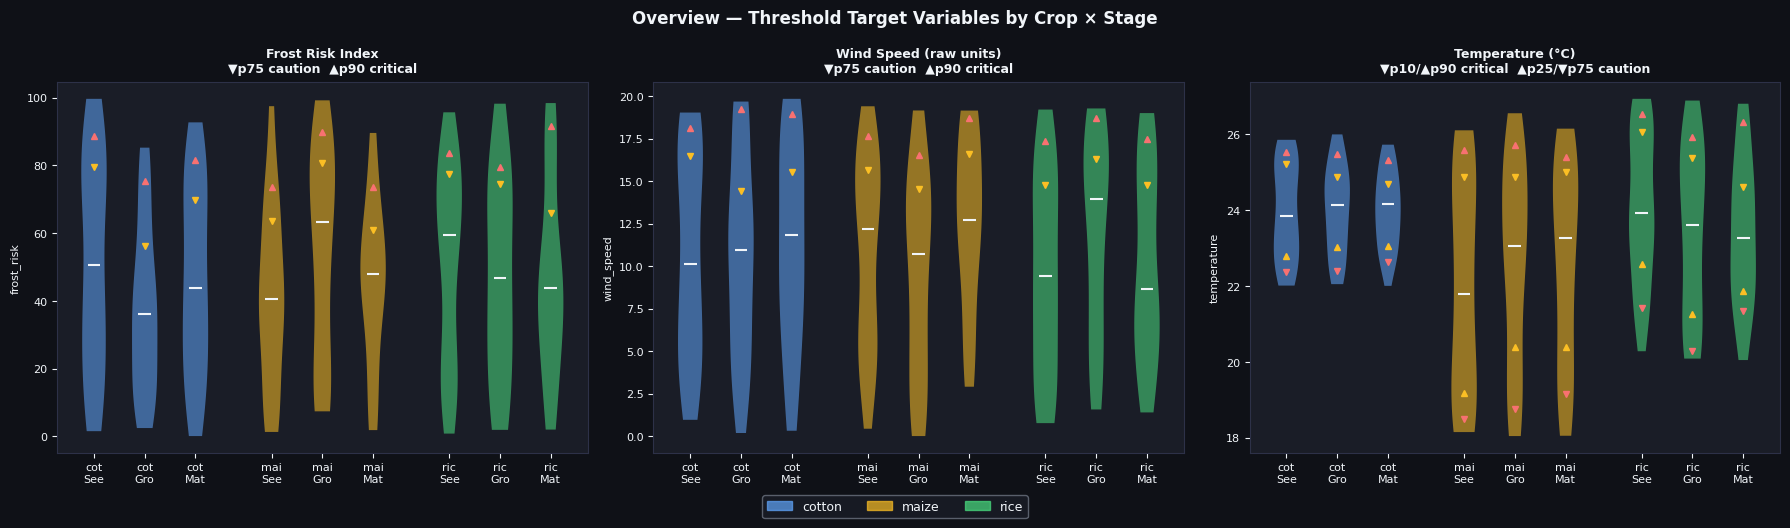

In [3]:
# ── Overview: distributions of the three threshold variables ──────────────────
# direction drives which percentile markers are shown — derived from data
TARGET_COLS = [
    ('frost_risk',  'Frost Risk Index',        'upper'),
    ('wind_speed',  'Wind Speed (raw units)',   'upper'),
    ('temperature', 'Temperature (°C)',         'two-sided'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Overview — Threshold Target Variables by Crop × Stage',
             color=WHITE, fontsize=12, fontweight='bold')

for ax, (col, label, direction) in zip(axes, TARGET_COLS):
    positions, data_list, tick_labels = [], [], []
    pos = 0
    for crop in CROPS:
        for stage in sorted(STAGE_MAP):
            grp = df.loc[(df['label']==crop) & (df['growth_stage']==stage), col]
            data_list.append(grp.values)
            positions.append(pos)
            tick_labels.append(f'{crop[:3]}\n{STAGE_MAP[stage][:3]}')
            pos += 1
        pos += 0.5

    vp = ax.violinplot(data_list, positions=positions, showmedians=True, showextrema=False)
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(CROP_COLORS[CROPS[i // 3]])
        body.set_alpha(0.55)
    vp['cmedians'].set_color(WHITE); vp['cmedians'].set_linewidth(1.5)

    for pos_x, grp_data in zip(positions, data_list):
        s = pd.Series(grp_data)
        if direction in ('upper', 'two-sided'):
            ax.plot(pos_x, s.quantile(0.75), 'v', color=AMBER, markersize=5, zorder=5)
            ax.plot(pos_x, s.quantile(0.90), '^', color=RED,   markersize=5, zorder=5)
        if direction in ('lower', 'two-sided'):
            ax.plot(pos_x, s.quantile(0.25), '^', color=AMBER, markersize=5, zorder=5)
            ax.plot(pos_x, s.quantile(0.10), 'v', color=RED,   markersize=5, zorder=5)

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, fontsize=6.5)
    note = {'upper': '▼p75 caution  ▲p90 critical',
            'lower': '▲p25 caution  ▼p10 critical',
            'two-sided': '▼p10/▲p90 critical  ▲p25/▼p75 caution'}[direction]
    style_ax(ax, f'{label}\n{note}', ylabel=col)

patches = [mpatches.Patch(color=CROP_COLORS[c], label=c, alpha=0.7) for c in CROPS]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           labelcolor=WHITE, facecolor=AX_BG, edgecolor=GREY, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('threshold_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 1. Frost Risk Threshold

`frost_risk` is a 0–100 decimal index. Trigger direction: **upper** (`frost_risk ≥ threshold → flag`).

Stage-conditioning is agronomically essential — crops in the **flowering / Growing** stage suffer irreversible damage at lower frost exposure than seedlings or mature plants. Even where the data percentiles are similar across stages, the threshold is intentionally tighter at the Growing stage to encode this agronomic asymmetry.

- **caution** = 75th percentile — elevated risk, monitor closely  
- **critical** = 90th percentile — take protective action

In [4]:
# ── Build unified threshold_rulebook ──────────────────────────────────────────
# Key: threshold_rulebook[crop][growth_stage (int)]
# All thresholds are data-derived percentiles — no hardcoded values.
#
# frost_risk_caution   p75 frost_risk index   — elevated risk, monitor closely
# frost_risk_critical  p90 frost_risk index   — take protective action
# wind_caution         p75 wind_speed (raw)   — max safe speed; monitor above this
# wind_critical        p90 wind_speed (raw)   — dangerous; take action
# temp_cold_caution    p25 temperature °C     — chilling risk begins
# temp_cold_critical   p10 temperature °C     — severe cold stress / frost damage
# temp_heat_caution    p75 temperature °C     — heat stress begins (pollen sterility risk)
# temp_heat_critical   p90 temperature °C     — severe heat stress / photosynthesis breakdown

threshold_rulebook = {}
for (crop, stage), grp in df.groupby(['label', 'growth_stage']):
    threshold_rulebook.setdefault(crop, {})[int(stage)] = {
        'frost_risk_caution' : round(float(grp['frost_risk'].quantile(0.75)),  2),
        'frost_risk_critical': round(float(grp['frost_risk'].quantile(0.90)),  2),
        'wind_caution'       : round(float(grp['wind_speed'].quantile(0.75)),  2),
        'wind_critical'      : round(float(grp['wind_speed'].quantile(0.90)),  2),
        'temp_cold_caution'  : round(float(grp['temperature'].quantile(0.25)), 2),
        'temp_cold_critical' : round(float(grp['temperature'].quantile(0.10)), 2),
        'temp_heat_caution'  : round(float(grp['temperature'].quantile(0.75)), 2),
        'temp_heat_critical' : round(float(grp['temperature'].quantile(0.90)), 2),
        'n'                  : int(len(grp)),
    }

print(f'{"Crop":<8} {"St":>3}  {"FR-Caut":>8} {"FR-Crit":>8}  {"W-Caut":>7} {"W-Crit":>7}  '
      f'{"T-ColdC":>8} {"T-ColdX":>8}  {"T-HeatC":>8} {"T-HeatX":>8}   N')
print('-' * 94)
for crop, stages in threshold_rulebook.items():
    for stage, e in stages.items():
        print(f'{crop:<8} {stage:>3}  '
              f'{e["frost_risk_caution"]:>8} {e["frost_risk_critical"]:>8}  '
              f'{e["wind_caution"]:>7} {e["wind_critical"]:>7}  '
              f'{e["temp_cold_caution"]:>8} {e["temp_cold_critical"]:>8}  '
              f'{e["temp_heat_caution"]:>8} {e["temp_heat_critical"]:>8}   {e["n"]}')

Crop      St   FR-Caut  FR-Crit   W-Caut  W-Crit   T-ColdC  T-ColdX   T-HeatC  T-HeatX   N
----------------------------------------------------------------------------------------------
cotton     1     79.46     88.7    16.47   18.13     22.78    22.36      25.2    25.53   28
cotton     2     56.16    75.33    14.44   19.24     23.03     22.4     24.87    25.48   39
cotton     3     69.79     81.7    15.52   18.95     23.05    22.63     24.69    25.31   33
maize      1     63.58    73.46    15.66   17.67     19.19    18.49     24.87    25.59   35
maize      2     80.81    89.86    14.53   16.56     20.38    18.75     24.88    25.71   36
maize      3      61.0    73.65    16.58   18.73     20.38    19.15     25.01    25.39   29
rice       1     77.53    83.66    14.78   17.38     22.59    21.42     26.05    26.53   40
rice       2     74.53    79.51    16.29   18.73     21.25    20.28     25.38    25.92   28
rice       3     65.96    91.69    14.78   17.49     21.88    21.33     24.62 

In [ ]:
# ── Frost risk visualization ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(BG)
gs_fig = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.36)
fig.suptitle('Frost Risk Thresholds  (upper trigger: frost_risk ≥ threshold)',
             color=WHITE, fontsize=12, fontweight='bold', y=0.99)

FROST_COL     = 'frost_risk'
frost_col_max = df[FROST_COL].max()

# ── Panels 1–3: Distribution + threshold lines per crop ───────────────────────
for ci, crop in enumerate(CROPS):
    ax = fig.add_subplot(gs_fig[0, ci])
    for stage in sorted(STAGE_MAP):
        grp = df.loc[(df['label']==crop) & (df['growth_stage']==stage), FROST_COL]
        grp.plot.kde(ax=ax, color=STAGE_COLORS[stage], linewidth=2, label=f'Stage {stage}')
        entry = threshold_rulebook[crop][stage]
        ax.axvline(entry['frost_risk_caution'],  color=STAGE_COLORS[stage], linewidth=1.2, linestyle='--', alpha=0.7)
        ax.axvline(entry['frost_risk_critical'], color=STAGE_COLORS[stage], linewidth=1.8, linestyle=':',  alpha=0.9)
    min_caution = min(v['frost_risk_caution'] for v in threshold_rulebook[crop].values())
    ax.axvspan(min_caution, frost_col_max, color=RED, alpha=0.07)
    ax.legend(fontsize=7.5, labelcolor=WHITE, facecolor=AX_BG, edgecolor=GREY)
    style_ax(ax, f'{crop.capitalize()} — Frost Risk Distribution\n(-- caution  ··· critical)',
             xlabel='frost_risk index', ylabel='Density')

# ── Build matrices from rulebook ──────────────────────────────────────────────
stage_keys   = sorted(STAGE_MAP.keys())
stage_labels = [str(s) for s in stage_keys]

matrix_caut = np.array([[threshold_rulebook[c][s]['frost_risk_caution']
                          for s in stage_keys] for c in CROPS])
matrix_crit = np.array([[threshold_rulebook[c][s]['frost_risk_critical']
                          for s in stage_keys] for c in CROPS])
gap_matrix  = matrix_crit - matrix_caut

# ── Panel 4: Caution heatmap ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs_fig[1, 0])
im4 = ax4.imshow(matrix_caut, cmap='YlOrRd', aspect='auto',
                 vmin=matrix_caut.min(), vmax=matrix_caut.max())
ax4.set_xticks(range(3)); ax4.set_xticklabels(stage_labels, fontsize=9)
ax4.set_yticks(range(len(CROPS))); ax4.set_yticklabels(CROPS, fontsize=9)
for r in range(matrix_caut.shape[0]):
    for c in range(matrix_caut.shape[1]):
        ax4.text(c, r, f'{matrix_caut[r,c]:.1f}', ha='center', va='center',
                 color='#111', fontsize=10, fontweight='bold')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04).ax.tick_params(colors=WHITE, labelsize=7)
style_ax(ax4, 'Caution (p75)\nfrost_risk ≥ value → monitor')

# ── Panel 5: Critical heatmap ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs_fig[1, 1])
im5 = ax5.imshow(matrix_crit, cmap='OrRd', aspect='auto',
                 vmin=matrix_crit.min(), vmax=matrix_crit.max())
ax5.set_xticks(range(3)); ax5.set_xticklabels(stage_labels, fontsize=9)
ax5.set_yticks(range(len(CROPS))); ax5.set_yticklabels(CROPS, fontsize=9)
for r in range(matrix_crit.shape[0]):
    for c in range(matrix_crit.shape[1]):
        ax5.text(c, r, f'{matrix_crit[r,c]:.1f}', ha='center', va='center',
                 color='#111', fontsize=10, fontweight='bold')
plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04).ax.tick_params(colors=WHITE, labelsize=7)
style_ax(ax5, 'Critical (p90)\nfrost_risk ≥ value → take action')

# ── Panel 6: Warning window (critical − caution) ──────────────────────────────
ax6 = fig.add_subplot(gs_fig[1, 2])
im6 = ax6.imshow(gap_matrix, cmap='RdYlGn_r', aspect='auto',
                 vmin=0, vmax=gap_matrix.max())
ax6.set_xticks(range(3)); ax6.set_xticklabels(stage_labels, fontsize=9)
ax6.set_yticks(range(len(CROPS))); ax6.set_yticklabels(CROPS, fontsize=9)
for r in range(gap_matrix.shape[0]):
    for c in range(gap_matrix.shape[1]):
        ax6.text(c, r, f'{gap_matrix[r,c]:.1f}', ha='center', va='center',
                 color='#111', fontsize=10, fontweight='bold')
plt.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04).ax.tick_params(colors=WHITE, labelsize=7)
style_ax(ax6, 'Warning Window (critical − caution)\nSmaller = less time to react')

plt.savefig('frost_threshold_viz.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 2. Wind Speed Threshold

`wind_speed` is a max-only threshold — wind causes lodging, transpiration stress, and mechanical damage above a ceiling, not below it. Trigger direction: **upper** (`wind_speed ≥ threshold → flag`).

> **Unit note:** The raw dataset values range 0–19.84. If these are **m/s**, multiply by 3.6 to convert to km/h (e.g., 15 m/s = 54 km/h — moderate gale, damaging to tall crops). If already in km/h, 15 km/h is a gentle breeze and thresholds would need domain adjustment. Confirm with the data source.

Stage-conditioning: tall crops (**maize**) at **Mature** stage have the highest lodging risk. Seedling-stage plants are low-profile but more susceptible to uprooting. Growing-stage cotton is vulnerable to boll damage.

In [ ]:
# ── Wind speed visualization ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(BG)
gs_fig = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.36)
fig.suptitle('Wind Speed Thresholds  (upper trigger: wind_speed ≥ threshold)',
             color=WHITE, fontsize=12, fontweight='bold', y=0.99)

WIND_COL = 'wind_speed'

# ── Panels 1–3: Distribution + threshold lines per crop ───────────────────────
for ci, crop in enumerate(CROPS):
    ax = fig.add_subplot(gs_fig[0, ci])
    for stage in sorted(STAGE_MAP):
        grp = df.loc[(df['label']==crop) & (df['growth_stage']==stage), WIND_COL]
        grp.plot.kde(ax=ax, color=STAGE_COLORS[stage], linewidth=2, label=f'Stage {stage}')
        entry = threshold_rulebook[crop][stage]
        ax.axvline(entry['wind_caution'],  color=STAGE_COLORS[stage], linewidth=1.2, linestyle='--', alpha=0.7)
        ax.axvline(entry['wind_critical'], color=STAGE_COLORS[stage], linewidth=1.8, linestyle=':',  alpha=0.9)
    min_safe = min(v['wind_caution'] for v in threshold_rulebook[crop].values())
    ax.axvspan(min_safe, df[WIND_COL].max() * 1.05, color=RED, alpha=0.07)
    ax.legend(fontsize=7.5, labelcolor=WHITE, facecolor=AX_BG, edgecolor=GREY)
    style_ax(ax, f'{crop.capitalize()} — Wind Speed Distribution\n(-- caution  ··· critical)',
             xlabel='wind_speed (raw units)', ylabel='Density')

stage_keys   = sorted(STAGE_MAP.keys())
stage_labels = [str(s) for s in stage_keys]

# ── Panel 4: Caution heatmap ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs_fig[1, 0])
mat_caut = np.array([[threshold_rulebook[c][s]['wind_caution'] for s in stage_keys] for c in CROPS])
im4 = ax4.imshow(mat_caut, cmap='Blues', aspect='auto')
ax4.set_xticks(range(3)); ax4.set_xticklabels(stage_labels, fontsize=9)
ax4.set_yticks(range(len(CROPS))); ax4.set_yticklabels(CROPS, fontsize=9)
for r in range(mat_caut.shape[0]):
    for c in range(mat_caut.shape[1]):
        ax4.text(c, r, f'{mat_caut[r,c]:.1f}', ha='center', va='center',
                 color='#111', fontsize=10, fontweight='bold')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04).ax.tick_params(colors=WHITE, labelsize=7)
style_ax(ax4, 'Caution (p75)  — raw units\nwind_speed ≥ value → monitor')

# ── Panel 5: Critical heatmap ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs_fig[1, 1])
mat_crit = np.array([[threshold_rulebook[c][s]['wind_critical'] for s in stage_keys] for c in CROPS])
im5 = ax5.imshow(mat_crit, cmap='Reds', aspect='auto')
ax5.set_xticks(range(3)); ax5.set_xticklabels(stage_labels, fontsize=9)
ax5.set_yticks(range(len(CROPS))); ax5.set_yticklabels(CROPS, fontsize=9)
for r in range(mat_crit.shape[0]):
    for c in range(mat_crit.shape[1]):
        ax5.text(c, r, f'{mat_crit[r,c]:.1f}', ha='center', va='center',
                 color='#111', fontsize=10, fontweight='bold')
plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04).ax.tick_params(colors=WHITE, labelsize=7)
style_ax(ax5, 'Critical (p90)  — raw units\nwind_speed ≥ value → take action')

# ── Panel 6: Stage sensitivity profile ────────────────────────────────────────
ax6 = fig.add_subplot(gs_fig[1, 2])
for crop in CROPS:
    caut_vals = [threshold_rulebook[crop][s]['wind_caution']  for s in stage_keys]
    crit_vals = [threshold_rulebook[crop][s]['wind_critical'] for s in stage_keys]
    ax6.plot(stage_labels, caut_vals, 'o--', color=CROP_COLORS[crop],
             linewidth=1.5, alpha=0.7, label=f'{crop} caution')
    ax6.plot(stage_labels, crit_vals, 's-',  color=CROP_COLORS[crop],
             linewidth=2,   alpha=1.0, label=f'{crop} critical')
ax6.legend(fontsize=7, labelcolor=WHITE, facecolor=AX_BG, edgecolor=GREY,
           ncol=2, loc='lower right')
style_ax(ax6, 'Wind Threshold by Stage\n(o-- caution,  s─ critical)',
         ylabel='wind_speed (raw units)', xlabel='growth stage')

plt.savefig('wind_threshold_viz.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 3. Temperature Threshold (Two-Sided)

`temperature` needs thresholds on **both sides** — crops suffer at cold extremes (chilling injury, germination failure) *and* at heat extremes (pollen sterility, photosynthesis breakdown, protein denaturation).

- **Cold side (lower trigger):** `temperature ≤ caution_min` → caution &nbsp;|&nbsp; `≤ critical_min` → critical
- **Heat side (upper trigger):** `temperature ≥ caution_max` → caution &nbsp;|&nbsp; `≥ critical_max` → critical
- **Safe operating window** = `caution_min` to `caution_max` — the band the crop tolerates comfortably

All values are derived from data percentiles: p10/p25 for cold, p75/p90 for heat.

In [ ]:
# ── Temperature threshold visualization (two-sided) ───────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(BG)
gs_fig = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.36)
fig.suptitle('Temperature Thresholds  (two-sided: cold ≤ threshold  |  heat ≥ threshold)',
             color=WHITE, fontsize=12, fontweight='bold', y=0.99)

TEMP_COL      = 'temperature'
temp_col_min  = df[TEMP_COL].min()
temp_col_max  = df[TEMP_COL].max()

# ── Panels 1–3: Distribution + both-sided threshold lines per crop ─────────────
for ci, crop in enumerate(CROPS):
    ax = fig.add_subplot(gs_fig[0, ci])
    for stage in sorted(STAGE_MAP):
        grp = df.loc[(df['label']==crop) & (df['growth_stage']==stage), TEMP_COL]
        grp.plot.kde(ax=ax, color=STAGE_COLORS[stage], linewidth=2, label=f'Stage {stage}')
        e = threshold_rulebook[crop][stage]
        ax.axvline(e['temp_cold_caution'],  color=STAGE_COLORS[stage], linewidth=1.2, linestyle='--', alpha=0.7)
        ax.axvline(e['temp_cold_critical'], color=STAGE_COLORS[stage], linewidth=1.8, linestyle=':',  alpha=0.9)
        ax.axvline(e['temp_heat_caution'],  color=STAGE_COLORS[stage], linewidth=1.2, linestyle='--', alpha=0.7)
        ax.axvline(e['temp_heat_critical'], color=STAGE_COLORS[stage], linewidth=1.8, linestyle=':',  alpha=0.9)
    max_cold_caut = max(v['temp_cold_caution'] for v in threshold_rulebook[crop].values())
    ax.axvspan(temp_col_min, max_cold_caut, color=BLUE, alpha=0.08)
    min_heat_caut = min(v['temp_heat_caution'] for v in threshold_rulebook[crop].values())
    ax.axvspan(min_heat_caut, temp_col_max, color=RED, alpha=0.08)
    ax.legend(fontsize=7.5, labelcolor=WHITE, facecolor=AX_BG, edgecolor=GREY)
    style_ax(ax, f'{crop.capitalize()} — Temperature Distribution\n'
                 f'(blue=cold zone, red=heat zone, -- caution, ··· critical)',
             xlabel='temperature (°C)', ylabel='Density')

# ── Build matrices from rulebook ──────────────────────────────────────────────
stage_keys   = sorted(STAGE_MAP.keys())
stage_labels = [str(s) for s in stage_keys]

mat_cold_crit = np.array([[threshold_rulebook[c][s]['temp_cold_critical'] for s in stage_keys] for c in CROPS])
mat_cold_caut = np.array([[threshold_rulebook[c][s]['temp_cold_caution']  for s in stage_keys] for c in CROPS])
mat_heat_caut = np.array([[threshold_rulebook[c][s]['temp_heat_caution']  for s in stage_keys] for c in CROPS])
mat_heat_crit = np.array([[threshold_rulebook[c][s]['temp_heat_critical'] for s in stage_keys] for c in CROPS])
mat_window    = mat_heat_caut - mat_cold_caut   # safe operating window width

def _heatmap(ax, matrix, cmap, title, fmt='.1f', suffix='°C'):
    im = ax.imshow(matrix, cmap=cmap, aspect='auto',
                   vmin=matrix.min(), vmax=matrix.max())
    ax.set_xticks(range(len(stage_labels))); ax.set_xticklabels(stage_labels, fontsize=9)
    ax.set_yticks(range(len(CROPS)));        ax.set_yticklabels(CROPS, fontsize=9)
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, f'{matrix[r,c]:{fmt}}{suffix}', ha='center', va='center',
                    color='#111', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors=WHITE, labelsize=7)
    style_ax(ax, title)

_heatmap(fig.add_subplot(gs_fig[1, 0]), mat_cold_crit, 'Blues_r',
         'Critical Cold (p10) °C\ntemp ≤ value → critical cold')

_heatmap(fig.add_subplot(gs_fig[1, 1]), mat_window, 'RdYlGn',
         'Safe Window Width (heat_caut − cold_caut)\nNarrow = more temperature-sensitive',
         fmt='.2f', suffix='')

_heatmap(fig.add_subplot(gs_fig[1, 2]), mat_heat_crit, 'YlOrRd',
         'Critical Heat (p90) °C\ntemp ≥ value → critical heat')

# ── Panel row 3: Thermal envelope — interval plot for each crop × stage ───────
ax_env = fig.add_subplot(gs_fig[2, :])
group_labels, cold_crits, cold_cauts, heat_cauts, heat_crits, y_pos = [], [], [], [], [], []
y = 0
for crop in CROPS:
    for stage in stage_keys:
        e = threshold_rulebook[crop][stage]
        cold_crits.append(e['temp_cold_critical']); cold_cauts.append(e['temp_cold_caution'])
        heat_cauts.append(e['temp_heat_caution']);  heat_crits.append(e['temp_heat_critical'])
        group_labels.append(f'{crop[:3]} / {stage}')
        y_pos.append(y); y += 1

y_arr = np.array(y_pos)
ax_env.barh(y_arr, np.array(cold_cauts) - np.array(cold_crits),
            left=cold_crits, height=0.4, color=BLUE, alpha=0.5, label='Cold danger (crit→caut)')
ax_env.barh(y_arr, np.array(heat_cauts) - np.array(cold_cauts),
            left=cold_cauts, height=0.4, color=GREEN, alpha=0.4, label='Safe window')
ax_env.barh(y_arr, np.array(heat_crits) - np.array(heat_cauts),
            left=heat_cauts, height=0.4, color=RED, alpha=0.5, label='Heat danger (caut→crit)')
for yi, (cc_min, cc_max) in enumerate(zip(cold_crits, heat_crits)):
    ax_env.axvline(cc_min, color=BLUE, alpha=0.15, linewidth=0.5)
    ax_env.axvline(cc_max, color=RED,  alpha=0.15, linewidth=0.5)

ax_env.set_yticks(y_pos); ax_env.set_yticklabels(group_labels, fontsize=8)
ax_env.legend(fontsize=8, labelcolor=WHITE, facecolor=AX_BG, edgecolor=GREY,
              loc='lower right', ncol=3)
style_ax(ax_env, 'Full Thermal Envelope per Crop × Stage\n'
                 '(blue=cold danger, green=safe window, red=heat danger)',
         xlabel='temperature (°C)')

plt.savefig('temp_threshold_viz.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Trigger Check Helpers

In [ ]:
def check_frost(crop, growth_stage, frost_risk_value):
    e = threshold_rulebook.get(crop, {}).get(int(growth_stage))
    if e is None: return None
    if frost_risk_value >= e['frost_risk_critical']: return 'critical'
    if frost_risk_value >= e['frost_risk_caution']:  return 'caution'
    return 'ok'

def check_wind(crop, growth_stage, wind_speed_value):
    e = threshold_rulebook.get(crop, {}).get(int(growth_stage))
    if e is None: return None
    if wind_speed_value >= e['wind_critical']: return 'critical'
    if wind_speed_value >= e['wind_caution']:  return 'caution'
    return 'ok'

def check_temperature(crop, growth_stage, temp_value):
    e = threshold_rulebook.get(crop, {}).get(int(growth_stage))
    if e is None: return None
    if temp_value <= e['temp_cold_critical']: return 'critical (cold)'
    if temp_value <= e['temp_cold_caution']:  return 'caution (cold)'
    if temp_value >= e['temp_heat_critical']: return 'critical (heat)'
    if temp_value >= e['temp_heat_caution']:  return 'caution (heat)'
    return 'ok'

def check_all(crop, growth_stage, frost_risk, wind_speed, temperature):
    """Run all threshold checks for a given crop × growth_stage reading."""
    return {
        'frost_risk' : check_frost(crop, growth_stage, frost_risk),
        'wind_speed' : check_wind(crop, growth_stage, wind_speed),
        'temperature': check_temperature(crop, growth_stage, temperature),
    }

# ── Demo — values chosen relative to each crop's actual thresholds ─────────────
print('Demo (values relative to each crop\'s actual thresholds):\n')
print(f'{"Crop":<8} {"St":>3}  {"frost_risk":>11} {"wind_spd":>10} {"temp°C":>8}  '
      f'{"Frost":>16} {"Wind":>16} {"Temp":>20}')
print('-' * 100)
for crop, stage in [('rice', 2), ('maize', 3), ('cotton', 1)]:
    e = threshold_rulebook[crop][stage]
    test_frost = e['frost_risk_critical'] + 1.0
    test_wind  = e['wind_caution'] - 1.0
    test_temp  = e['temp_cold_critical'] - 0.5
    result = check_all(crop, stage, test_frost, test_wind, test_temp)
    print(f'{crop:<8} {stage:>3}  {test_frost:>11.1f} {test_wind:>10.1f} {test_temp:>8.1f}  '
          f'{result["frost_risk"]:>16} {result["wind_speed"]:>16} {result["temperature"]:>20}')

## Export

In [ ]:
# ── Export — single unified threshold_rulebook ────────────────────────────────
OUT_DIR = os.path.dirname(os.path.abspath(FILE_PATH)).replace(
    os.path.join('Data_Setup', 'Datasets'), os.path.join('app', 'rules')
)
os.makedirs(OUT_DIR, exist_ok=True)

# Column descriptions — written as header comments in CSV, not as DataFrame columns
COL_DESCRIPTIONS = [
    ('crop',                'crop type (cotton, maize, rice)'),
    ('growth_stage',        'growth stage integer (1=seedling, 2=growing, 3=mature)'),
    ('frost_risk_caution',  'p75 frost_risk index — elevated risk, monitor closely'),
    ('frost_risk_critical', 'p90 frost_risk index — take protective action'),
    ('wind_caution',        'p75 wind_speed (raw dataset units) — max safe threshold'),
    ('wind_critical',       'p90 wind_speed (raw dataset units) — critical action threshold'),
    ('temp_cold_caution',   'p25 temperature °C — chilling risk begins'),
    ('temp_cold_critical',  'p10 temperature °C — severe cold stress'),
    ('temp_heat_caution',   'p75 temperature °C — heat stress begins'),
    ('temp_heat_critical',  'p90 temperature °C — severe heat stress'),
    ('n',                   'number of data rows in this crop × growth_stage group'),
]

DATA_COLS = [col for col, _ in COL_DESCRIPTIONS]

records = []
for crop, stages in threshold_rulebook.items():
    for stage, e in stages.items():
        records.append({'crop': crop, 'growth_stage': stage,
                        **{col: e[col] for col in DATA_COLS[2:]}})

df_flat = pd.DataFrame(records)[DATA_COLS]

# ── CSV with column descriptions as header comments ───────────────────────────
csv_path = os.path.join(OUT_DIR, 'threshold_rulebook.csv')
with open(csv_path, 'w') as f:
    for col, desc in COL_DESCRIPTIONS:
        f.write(f'# {col}: {desc}\n')
    f.write('\n')
    df_flat.to_csv(f, index=False)
print(f'threshold_rulebook.csv → {csv_path}')

# ── JSON (string keys for JSON compatibility) ──────────────────────────────────
def _str_keys(d):
    return {str(k): (_str_keys(v) if isinstance(v, dict) else v) for k, v in d.items()}

json_path = os.path.join(OUT_DIR, 'threshold_rulebook.json')
with open(json_path, 'w') as f:
    json.dump(_str_keys(threshold_rulebook), f, indent=2)
print(f'threshold_rulebook.json → {json_path}')

print(f'\n{df_flat.to_string(index=False)}')